In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mlxtend.feature_selection import SequentialFeatureSelector 
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

**The data provided are responses for a survey conducted in 2015 on a sample of 70 thousand people to assess the factors leading to getting diagnosed with diabetes.**

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0



### Exploratory Data Analysis ###

In [3]:
df.shape

(70692, 22)

In [4]:
# taking a random sample of 12000 record to make the process easier 
df = df.sample(12000, random_state=49)

In [5]:
# checking for null values
df.isna().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [6]:
# exploring columns
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [7]:
# exploring the unique values of each column
for col in df.columns:
    print(f'{col}:', df[col].unique())

Diabetes_binary: [0. 1.]
HighBP: [0. 1.]
HighChol: [0. 1.]
CholCheck: [1. 0.]
BMI: [24. 28. 22. 42. 31. 49. 26. 33. 34. 30. 32. 25. 21. 29. 19. 39. 43. 37.
 47. 23. 36. 35. 41. 27. 40. 55. 20. 38. 44. 48. 45. 18. 46. 50. 87. 51.
 67. 15. 58. 73. 53. 54. 63. 75. 17. 61. 52. 16. 59. 77. 79. 57. 13. 82.
 72. 66. 60. 92. 84. 65. 64. 62. 56. 89. 81. 14. 71.]
Smoker: [0. 1.]
Stroke: [0. 1.]
HeartDiseaseorAttack: [0. 1.]
PhysActivity: [1. 0.]
Fruits: [1. 0.]
Veggies: [1. 0.]
HvyAlcoholConsump: [0. 1.]
AnyHealthcare: [1. 0.]
NoDocbcCost: [1. 0.]
GenHlth: [2. 4. 5. 3. 1.]
MentHlth: [ 0. 30.  1.  8.  5. 10. 15. 20.  2. 25. 12.  4. 29.  3.  7.  6. 14. 21.
 18. 23. 13. 17. 26. 19. 28. 27.  9. 16. 11. 22. 24.]
PhysHlth: [ 2. 10. 30. 14.  0.  3.  1.  5. 15.  4.  8. 20.  7. 18. 29.  6.  9. 28.
 25. 12. 16. 27. 21. 13. 17. 24. 11. 22. 23. 26. 19.]
DiffWalk: [0. 1.]
Sex: [0. 1.]
Age: [ 6. 10. 13.  8.  9. 12. 11.  7.  4.  1.  3.  5.  2.]
Education: [6. 4. 3. 5. 2. 1.]
Income: [5. 1. 4. 7. 6. 8. 3. 2.]


In [8]:
# exploring the distribution of BMI
fig = px.histogram(df, x='BMI', title= 'BMI Distribution')
fig.update_layout(template='plotly_white', yaxis_title=None)
fig.show()

In [9]:
fig = px.box(df, x='BMI', title= 'BMI Distribution')
fig.update_layout(template='plotly_white', yaxis_title=None)
fig.show()

In [10]:
# visualizing the respondents answer to the question "In the previous month, how many days have you felt that your mental health was bad"
fig = px.box(df, x='MentHlth', title= 'How many days in the previous month your mental health was bad', labels={'MentHlth': 'Mental Health'})
fig.update_layout(template='plotly_white', yaxis_title=None)
fig.show()

In [11]:
# visualizing the respondents answer to the question "In the previous month, how many days have you felt that your physical health was bad"

fig = px.box(df, x='PhysHlth', title= 'How many days in the previous month your physical health was bad', labels={'PhysHlth': 'Physical Health'})
fig.update_layout(template='plotly_white', yaxis_title=None)
fig.show()

In [12]:
# create a copy of the data to categorize the numerical columns to visualize them better
df_categories = df.copy()

# map categories for numerical columns
df_categories['Sex'] = df_categories['Sex'].map({0: 'Female', 1: 'Male'})
df_categories['GenHlth'] = df_categories['GenHlth'].map({1: 'Excellent', 2: 'Very Good', 3: 'Good', 4: 'Fair', 5: 'Poor'})
df_categories['Age'] = df_categories['Age'].map({1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44', 6: '45-49', 7: '50-54',8: '55-59', 9: '60-64', 10: '65-69', 11: '70-74', 12: '75-79', 13: '80+'})
edu = {1: 'Never Attended', 2: 'Elementary', 3: 'High School dropout', 4: 'High School graduate', 5: 'College dropout', 6: 'College graduate'}
df_categories['Education'] = df_categories['Education'].map(edu)
income = {1: 'Low Income', 2: 'Low Income', 3: 'Low Income', 4: 'Lower-Middle Income',  5: 'Lower-Middle Income', 6: 'Upper-Middle Income', 7: 'Upper-Middle Income', 8: 'High Income'}
df_categories['Income'] = df_categories['Income'].map(income)

# create bins for scaled values
bmi_bins = [0, 18.5, 24.9, 29.9, 34.9, 39.9, 100]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obesity I', 'Obesity II', 'Obesity III']
df_categories['bmi_category'] = pd.cut(df['BMI'], bins=bmi_bins, labels=bmi_labels, right=True)

hlth_bins = [0, 10, 20, 30]
hlth_labels = ['Well', 'Unwell', 'Severly Unwell']
df_categories['MentHlth'] = pd.cut(df['MentHlth'], bins=hlth_bins, labels=hlth_labels, right=True)
df_categories['PhysHlth'] = pd.cut(df['PhysHlth'], bins=hlth_bins, labels=hlth_labels, right=True)

# mapping binary columns
bin_cols = ['Diabetes_binary', 'HighBP', 'HighChol', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
       'HvyAlcoholConsump']

for col in bin_cols:
    df_categories[col] = df_categories[col].map({0: 'No', 1:'Yes'})


In [14]:
cols = ['Diabetes_binary', 'HighBP', 'HighChol', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
          'HvyAlcoholConsump', 'Sex']

# customize titles for each binary column
titles = ['Diabetes', 'High blood pressure', 'High cholestrol', 'Smoker', 'Stroke', 'Heart Disease/Attack', 'Physical Activity',
          'Alcholic', 'Sex']

# create a 3x3 subplot to visualize the binary columns using pie charts
fig = make_subplots(
    rows=3, cols=3,
    subplot_titles=titles,
    specs=[[{'type': 'domain'}]*3]*3  # each cell holds a pie chart
    )

# loop through each column to add it to the subplot with a customized title and percentage of each value
for i, (col, title) in enumerate(zip(cols, titles)):
    counts = df_categories[col].value_counts().reset_index()
    counts.columns = [col, 'Count']

    row = i // 3 + 1
    col_pos = i % 3 + 1

    # add the figure to the subplot
    fig.add_trace(
        go.Pie(labels=counts[col], values=counts['Count'], textinfo='percent+label'),
        row=row, col=col_pos
    )
# customize the graph
fig.update_layout(
    height=1100,
    title_text='Distribution of Binary Columns',
    template='plotly_white',
    showlegend=False
)

fig.show()


In [15]:
# create a list of factors to get a better look at their impact on the diabetes diagnosis
factors = ['HighBP', 'HighChol', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump']

# create a list of titles for the factors 
fac_titles = ['High blood pressure', 'High cholestrol', 'Smoker', 'Stroke', 'Heart Disease/Attack', 'Physical Activity', 'Alcholic']

# loop through each factor and visualize it with a stacked bar chart to show the percentage of each category
for col, title in zip(bin_cols, fac_titles):
    fig = px.histogram(df_categories, x=col, color='Diabetes_binary', histnorm='percent',
     labels={f'{col}': f'{title}', 'Diabetes_binary': 'Diabetic'}, title=title)
    fig.update_layout(template='plotly_white', yaxis_title=None, xaxis_title=title)
    fig.show()

In [16]:
# declaring the order of the general health
health_order = ['Excellent', 'Very Good', 'Good', 'Fair', 'Poor']
df_categories['GenHlth'] = pd.Categorical(df_categories['GenHlth'], categories=health_order, ordered=True)
counts = df_categories['GenHlth'].value_counts().sort_index().reset_index()
counts.columns = ['GenHlth', 'counts']

# visualize the answer via horizontal bar chart
fig = px.bar(counts, x='counts', y='GenHlth', orientation='h', color='GenHlth', labels={'GenHlth': 'General Health'})
fig.update_layout(template='plotly_white', showlegend=False, xaxis_title=None)
fig.show()

In [17]:
# mapping age bins into the age column and sorting them ascendingly 
order = ['18-24','25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+']
df_categories['Age'] = pd.Categorical(df_categories['Age'], categories=order, ordered=True)
counts = df_categories['Age'].value_counts().sort_index().reset_index()

counts.columns = ['Age', 'count']

# create a bar chart for age bins
fig = px.bar(counts, x='Age', y='count', title='Age Distribution')
fig.update_layout(template='plotly_white', showlegend=False, yaxis_title=None)
fig.show()

In [18]:
# mapping education levels to the numerical column
order = ['Never Attended', 'Elementary', 'High School dropout', 'High School graduate', 'College dropout', 'College graduate']

df_categories['Education'] = pd.Categorical(df_categories['Education'], categories=order, ordered=True)
counts = df_categories['Education'].value_counts().sort_index().reset_index()
counts.columns = ['Education', 'Count']

# create a bar chart 
fig = px.bar(counts, x='Education', y='Count', color='Education')
fig.update_layout(template='plotly_white', showlegend=False, yaxis_title=None)
fig.show()

### Dimensionality Reduction ###

Preprocessing

In [19]:
# create a correlation matrix to possibily eliminate features that are highly correlated 
corr_matrix = df.corr()

fig = go.Figure(data=go.Heatmap(z=corr_matrix.values, x=corr_matrix.columns, y=corr_matrix.columns,
    colorscale='RdBu', zmin=-1, zmax=1, colorbar=dict(title="Correlation")))

fig.update_layout(title='Correlation Heatmap', xaxis_nticks=36, width=900, height=900)
fig.show()

In [53]:
# split the data into X: independent variables and y: target/dependent variable
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

In [54]:
# split the data into taining and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=60)

In [57]:
# loop over all possible number of feature
k_values = range(1, X_train.shape[1] + 1)  
mean_scores = []
selected_features_dict = {}

for k in k_values:
    selector = SelectKBest(score_func=chi2, k=k)
    selector.fit(X_train, y_train)  # Fit only the selector to get feature names
    
    # Get selected feature names
    mask = selector.get_support()
    selected_feature_names = X_train.columns[mask].tolist()
    selected_features_dict[k] = selected_feature_names

    # Now build pipeline and evaluate model
    model = Pipeline([
        ('feature_selection', selector),
        ('svm', SVC(kernel='rbf', class_weight='balanced'))
    ])
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='recall')
    mean_scores.append(scores.mean())

In [58]:
fig = px.line(x=k_values, y=mean_scores, markers=True, title='No. of Features Vs Mean Recall')
fig.update_layout(xaxis_title='Number of Features', yaxis_title='Mean Recall Score')
fig.show()

In [ ]:
selected_features_dict[6]

['HighBP', 'BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age']

In [61]:
X_train= X_train[['HighBP', 'BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age']]
X_test= X_test[['HighBP', 'BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age']]

In [69]:
model = SVC()

In [70]:
# evaluating model performance using cross validation 

k_fold = KFold(n_splits=5)
scores = cross_val_score(model, X_train, y_train, cv = k_fold, scoring='recall')
print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())

Cross Validation Scores:  [0.79361179 0.8062201  0.796875   0.77712952 0.79559364]
Average CV Score:  0.7938860092286845


In [71]:
# perform grid search to fine tune the hyperparameters of the model
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)

grid_search.best_score_

0.8101540081458856

### Testing model and evaluating its performance ###

In [74]:
y_pred = grid_search.predict(X_test)

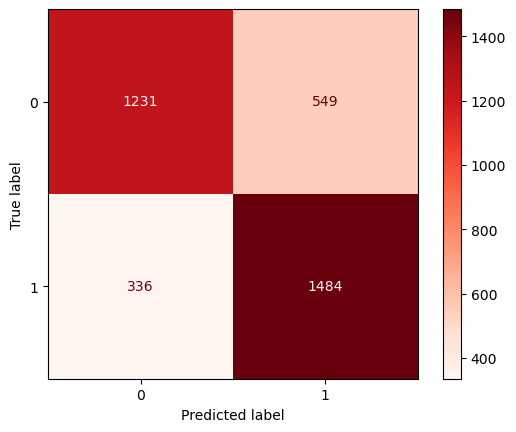

In [75]:
#Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_mat)
disp.plot(cmap='Reds')
plt.show()